V = -26.957 mV


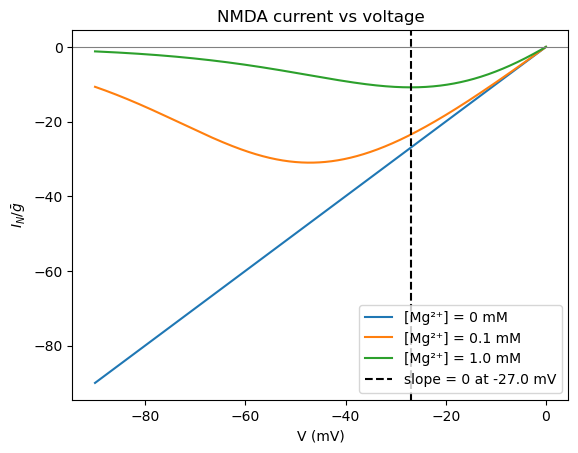

In [2]:
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt

V0 = 16.13
EN = 0.0

def B(V, Mg):
    return 1.0 / (1 + (Mg / 3.57) * np.exp(-V / V0))

def slope_condition(V, Mg=1.0):
    b = B(V, Mg)
    return 1 + (V - EN) * (1 - b) / V0

# Find where slope vanishes
V_zero = brentq(slope_condition, -80, -5)
print(f"V = {V_zero:.3f} mV")

# Plot
V = np.linspace(-90, 0, 1000)

for Mg in [0, 0.1, 1.0]:
    plt.plot(V, B(V, Mg) * (V - EN), label=f'[Mg^2+] = {Mg} mM')

plt.axvline(x=V_zero, color='k', linestyle='--',
            label=f'slope = 0 at {V_zero:.1f} mV')
plt.axhline(y=0, color='gray', linewidth=0.8)
plt.xlabel('V (mV)')
plt.ylabel('$I_N / \\bar{g}$')
plt.title('NMDA current vs voltage')
plt.legend()
plt.savefig('prob2c.png')
plt.show()